In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from pathlib import Path

In [3]:
data_dir = Path("../data/survey_of_consumer_finance")
figs_dir = Path("../figs")
df = pd.read_csv(data_dir / "scf2022.csv")
df

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,3027.956120,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,2,1
1,1,12,3054.900065,2,70,5,9,3,2,2,...,4,2,5,2,1,8,3,3,2,1
2,1,13,3163.637766,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,1,1
3,1,14,3166.228463,2,70,5,9,3,2,2,...,3,2,4,1,1,6,3,2,1,1
4,1,15,3235.624715,2,70,5,9,3,2,2,...,3,2,4,2,1,8,3,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22970,4603,46031,1705.225499,2,40,2,8,2,2,2,...,1,2,1,2,1,1,3,3,2,1
22971,4603,46032,1713.918975,2,40,2,8,2,2,2,...,1,2,1,1,1,1,3,2,1,1
22972,4603,46033,1689.140933,2,40,2,8,2,2,2,...,1,2,1,2,1,1,3,3,2,1
22973,4603,46034,1714.060239,2,40,2,8,2,2,2,...,1,2,1,2,1,1,3,3,2,1


In [4]:
def weighted_mean(group, variable):
    return np.average(
        group[variable],
        weights=group["WGT"]
    )

profile = df.groupby("AGE").apply(
    lambda g: pd.Series({
        "income": weighted_mean(g, "INCOME"),
        "wealth": weighted_mean(g, "NETWORTH"),
        "liquid_wealth": weighted_mean(g, "LIQ")
    }),
    include_groups=False
)
profile

,income,wealth,liquid_wealth
AGE,,,
18,168622.244490,2.363872e+04,3000.000000
19,16951.057804,-8.110399e+03,2848.574065
20,41948.374659,1.456603e+04,7030.868860
21,25343.061110,1.152845e+04,11243.837481
22,35870.657774,1.218631e+05,5113.101361
...,...,...,...
91,36354.431329,2.938736e+06,1351.512676
92,64144.940733,9.586703e+05,110843.681673
93,31498.849957,2.994547e+05,11474.423688


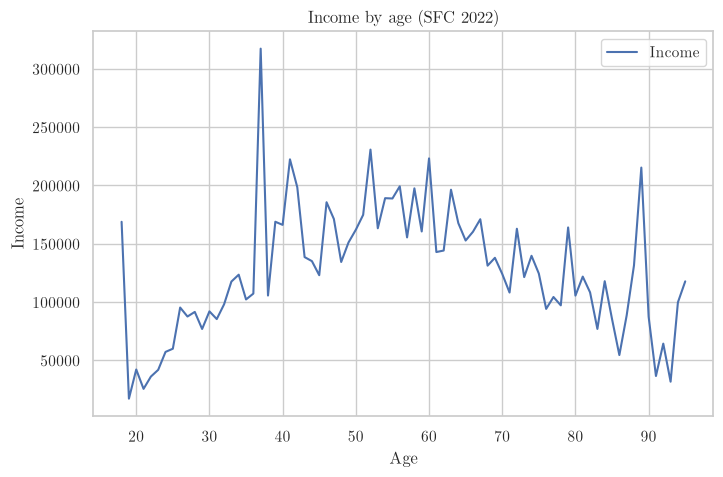

In [5]:
sns.set_theme(
    style="whitegrid",
    font="Latin Modern Roman"
)

plt.figure(figsize=(8, 5))
ax = sns.lineplot(
    data=profile,
    x="AGE",
    y="income",
    label="Income",
)
ax.set_title("Income by age (SFC 2022)")
ax.set_xlabel("Age")
ax.set_ylabel("Income")

plt.savefig(
    figs_dir / "income_by_age_sfc_2022.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


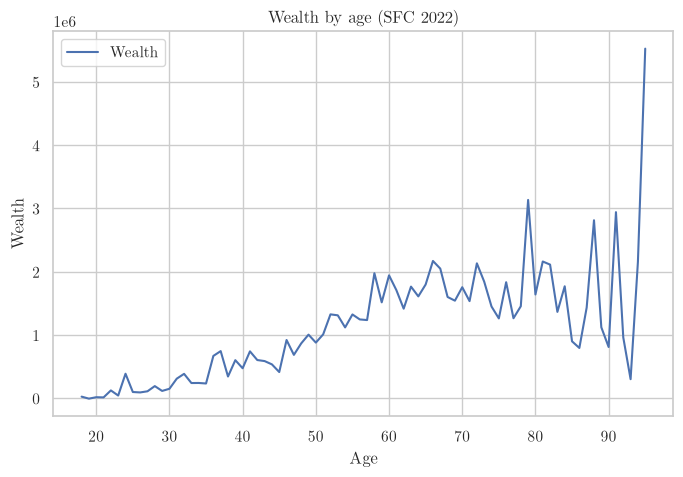

In [6]:
sns.set_theme(
    style="whitegrid",
    font="Latin Modern Roman"
)

plt.figure(figsize=(8, 5))
ax= sns.lineplot(
    data=profile,
    x="AGE",
    y="wealth",
    label="Wealth"
)
ax.set_title("Wealth by age (SFC 2022)")
ax.set_xlabel("Age")
ax.set_ylabel("Wealth")

plt.savefig(
    figs_dir / "wealth_by_age_sfc_2022.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [7]:
for power in range(1, 5):
    df[f"age_power{power}"] = df["AGE"] ** power

def quartic_regression(data, outcome):
    X = data[
        ["age_power1", "age_power2", "age_power3", "age_power4"]
    ]
    X = sm.add_constant(X)
    y= data[outcome]

    model = sm.WLS(
        y,
        X,
        weights=data["WGT"]
    ).fit()
    return model

income_model = quartic_regression(df, "INCOME")
wealth_model = quartic_regression(df, "NETWORTH")

results_table = summary_col(
    [income_model, wealth_model],
    stars=True,
        model_names=["Income Profile", "Wealth Profile"],
        info_dict={
            "N": lambda x: f"{int(x.nobs)}"
        },
)
print(results_table)


               Income Profile Wealth Profile
--------------------------------------------
const          -151157.0415   4245720.3265  
               (269240.2403)  (2985897.9035)
age_power1     5951.3966      -392988.7364  
               (22947.3241)   (254487.8393) 
age_power2     244.3660       12246.5816    
               (689.1291)     (7642.5023)   
age_power3     -6.4839        -139.9362     
               (8.7016)       (96.5016)     
age_power4     0.0375         0.5409        
               (0.0393)       (0.4354)      
R-squared      0.0027         0.0057        
R-squared Adj. 0.0025         0.0055        
N              22975          22975         
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


/var/folders/9b/4f2bxvvd1mj1hdx98fkh1lcm0000gn/T/ipykernel_23850/2164120902.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"age_power{power}"] = df["AGE"] ** power
/var/folders/9b/4f2bxvvd1mj1hdx98fkh1lcm0000gn/T/ipykernel_23850/2164120902.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"age_power{power}"] = df["AGE"] ** power
/var/folders/9b/4f2bxvvd1mj1hdx98fkh1lcm0000gn/T/ipykernel_23850/2164120902.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

In [8]:
age_grid = np.arange(df["AGE"].min(), df["AGE"].max())
X_grid = pd.DataFrame({
    "age_power1": age_grid,
    "age_power2": age_grid **2,
    "age_power3": age_grid **3,
    "age_power4": age_grid **4,
})
X_grid = sm.add_constant(X_grid)

income_pred = income_model.predict(X_grid)
wealth_pred = wealth_model.predict(X_grid)

profile_fitted = profile.copy()
profile_fitted["income_hat"] = pd.Series(
    income_pred.to_numpy(),
    index=age_grid
)
profile_fitted["wealth_hat"] = pd.Series(
    wealth_pred.to_numpy(),
    index=age_grid
)
profile_fitted

,income,wealth,liquid_wealth,income_hat,wealth_hat
AGE,,,,,
18,168622.244490,2.363872e+04,3000.000000,1269.473684,3.804939e+05
19,16951.057804,-8.110399e+03,2848.574065,10554.924380,3.106244e+05
20,41948.374659,1.456603e+04,7030.868860,19752.645791,2.516399e+05
21,25343.061110,1.152845e+04,11243.837481,28841.303833,2.029538e+05
22,35870.657774,1.218631e+05,5113.101361,37800.465416,1.639927e+05
...,...,...,...,...,...
91,36354.431329,2.938736e+06,1351.512676,102328.955461,1.541194e+06
92,64144.940733,9.586703e+05,110843.681673,105182.414771,1.532193e+06
93,31498.849957,2.994547e+05,11474.423688,108758.568754,1.525385e+06


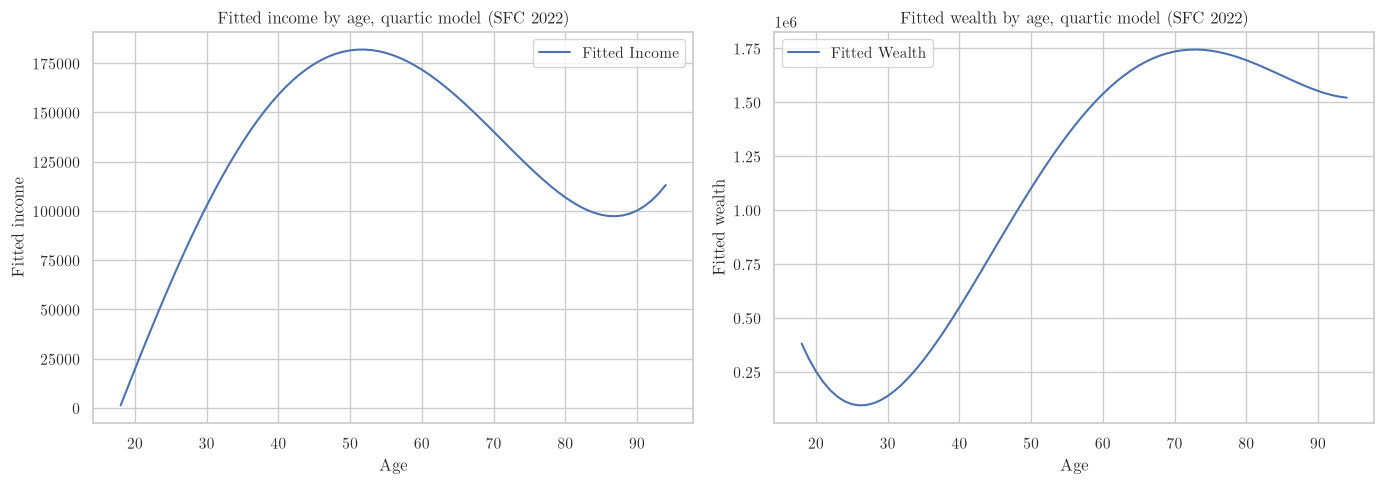

In [9]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

sns.set_theme(
    style="whitegrid",
    font="Latin Modern Roman"
)

sns.lineplot(
    data=profile_fitted,
    x="AGE",
    y="income_hat",
    label="Fitted Income",
    ax=axes[0]
)
axes[0].set_title("Fitted income by age, quartic model (SFC 2022)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Fitted income")

sns.lineplot(
    data=profile_fitted,
    x="AGE",
    y="wealth_hat",
    label="Fitted Wealth",
    ax=axes[1]
)
axes[1].set_title("Fitted wealth by age, quartic model (SFC 2022)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Fitted wealth")

plt.tight_layout()

plt.savefig(
    figs_dir / "fitted_income_wealth_by_age_sfc_2022.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

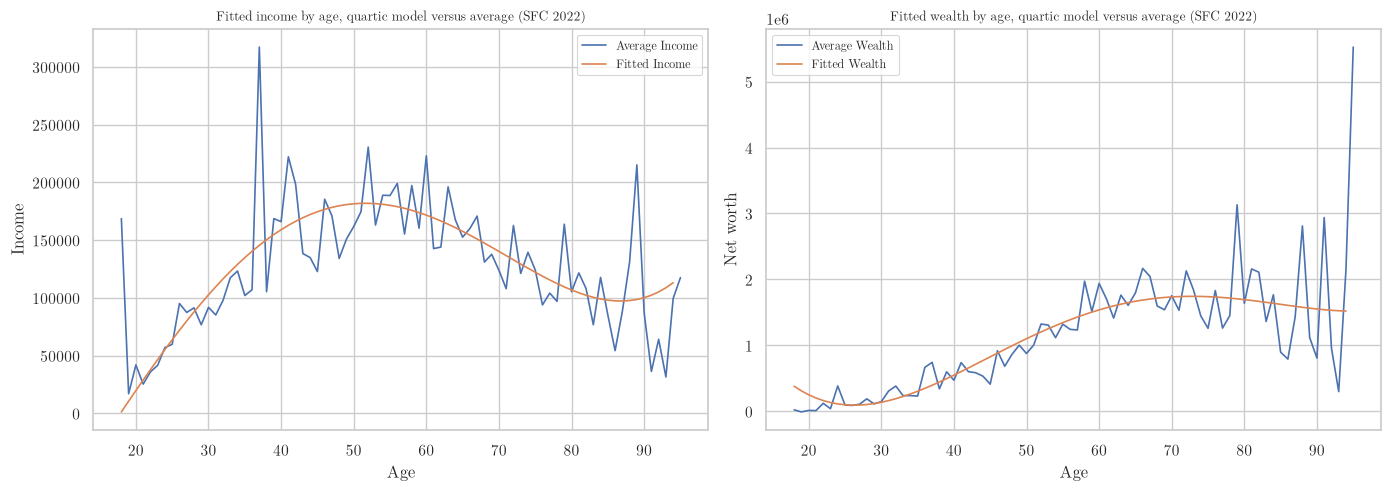

In [10]:
fig, axes = plt.subplots(
    1,2,
    figsize =(14, 5)
)

sns.set_theme(
    style="whitegrid",
    context="paper",
    font="Latin Modern Roman"
)

profile_fitted_long = profile_fitted.reset_index().melt(
    id_vars="AGE",
    value_vars=["income", "wealth", "income_hat", "wealth_hat"],
    var_name="Variables",
    value_name="Value"
)

sns.lineplot(
    data=profile_fitted_long[
        profile_fitted_long["Variables"].isin(["income","income_hat"])
    ],
    x="AGE",
    y="Value",
    hue="Variables",
    ax=axes[0]
)
axes[0].set_title("Fitted income by age, quartic model versus average (SFC 2022)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Income")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles,
    ["Average Income", "Fitted Income"],
    title=None
)
sns.lineplot(
    data=profile_fitted_long[
        profile_fitted_long["Variables"].isin(["wealth", "wealth_hat"])
    ],
    x= "AGE",
    y="Value",
    hue = "Variables",
    ax = axes[1]
)
axes[1].set_title("Fitted wealth by age, quartic model versus average (SFC 2022)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Net worth")
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles,
    ["Average Wealth", "Fitted Wealth"],
    title=None
)

plt.tight_layout()

plt.savefig(
    figs_dir / "fitted_income_wealth_by_age_with_average_sfc_2022.pdf",
    format = "pdf",
    bbox_inches="tight"
)

<Axes: xlabel='AGE', ylabel='Value'>

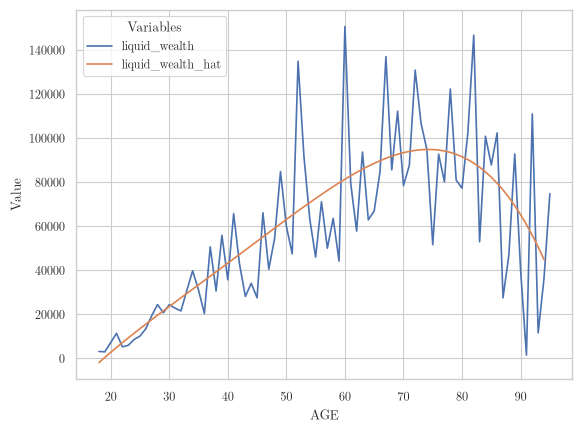

In [22]:
liquid_wealth_model = quartic_regression(df, "LIQ")
liquid_wealth_pred = liquid_wealth_model.predict(X_grid)
profile_fitted["liquid_wealth_hat"] = pd.Series(
    liquid_wealth_pred.to_numpy(),
    index=age_grid
)
profile_fitted_long = profile_fitted.reset_index().melt(
    id_vars="AGE",
    value_vars=["income", "wealth", "income_hat", "wealth_hat", "liquid_wealth", "liquid_wealth_hat"],
    var_name="Variables",
    value_name="Value"
)

sns.set_theme(
    style="whitegrid",
    context="paper",
    font="Latin Modern Roman"
)
sns.lineplot(
    data=profile_fitted_long[
        profile_fitted_long["Variables"].isin(["liquid_wealth","liquid_wealth_hat"])
    ],
    x="AGE",
    y="Value",
    hue="Variables"
)